<a href="https://colab.research.google.com/github/jaisweta-naarrayanan/Handwritten-Digit-Recognition/blob/main/Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Handwritten Digit Recognition

## Setup: Load and Preprocess Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load data
X_train = pd.read_csv('X_train.csv').values
X_test = pd.read_csv('X_test.csv').values
y_train = pd.read_csv('y_train.csv').values.ravel()
y_test = pd.read_csv('y_test.csv').values.ravel()
y_MLL_train = pd.read_csv('y_MLL_train.csv').values
y_MLL_test = pd.read_csv('y_MLL_test.csv').values

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"y_MLL_train shape: {y_MLL_train.shape} [is_even, is_greater_than_5, is_prime]")
print(f"y_MLL_test shape: {y_MLL_test.shape}")

X_train shape: (1347, 64)
X_test shape: (450, 64)
y_train shape: (1347,)
y_test shape: (450,)
y_MLL_train shape: (1347, 3) [is_even, is_greater_than_5, is_prime]
y_MLL_test shape: (450, 3)


In [ ]:
# Normalize pixel features to [0, 1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Standardize features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_norm)
X_test_scaled = scaler.transform(X_test_norm)

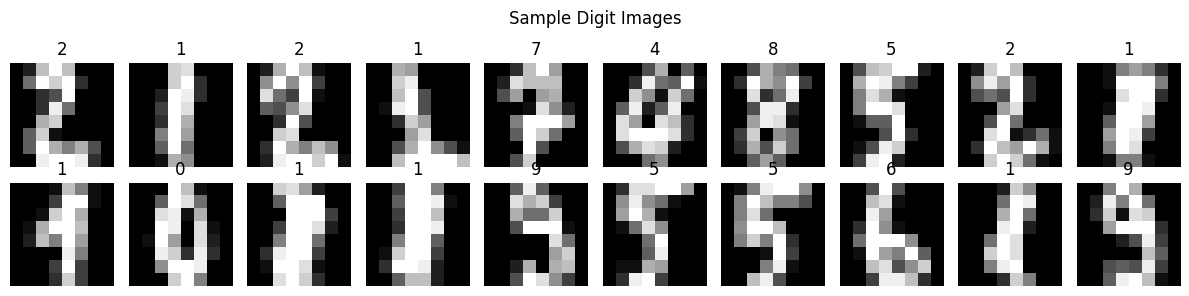

In [ ]:
# Visualize some digit images
fig, axes = plt.subplots(2, 10, figsize=(12, 3))
for i in range(20):
    ax = axes[i // 10, i % 10]
    ax.imshow(X_train[i].reshape(8, 8), cmap='gray')
    ax.set_title(str(y_train[i]))
    ax.axis('off')
plt.suptitle('Sample Digit Images')
plt.tight_layout()
plt.show()

---
## Part 1: Multi-Class Classification with Softmax (10-way)

### 1(a) Train multinomial (softmax) logistic regression

In [ ]:
# Train multinomial logistic regression with regularization
softmax_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, C=1.0)
softmax_model.fit(X_train_scaled, y_train)

print("Softmax model trained successfully.")
print(f"Coefficients shape: {softmax_model.coef_.shape}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Softmax model trained successfully.
Coefficients shape: (10, 64)


### 1(b)(i) Plot coefficient distributions for class 0 (red) and class 7 (blue)

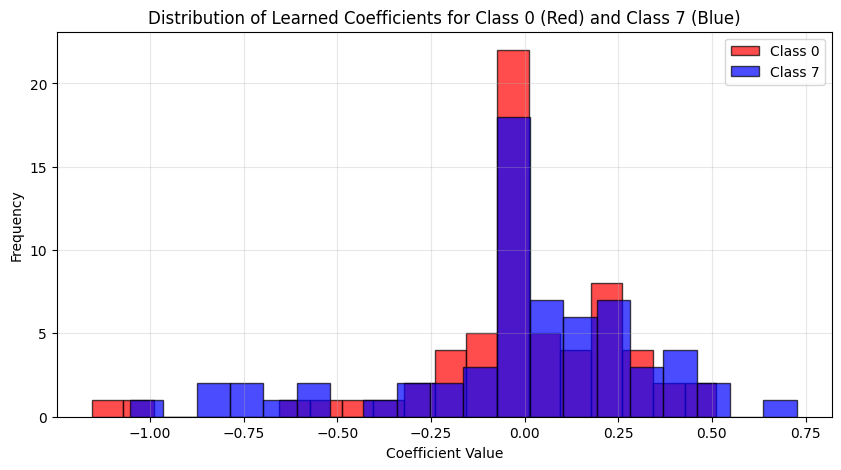

In [ ]:
# Get coefficients for class 0 and class 7
coef_class_0 = softmax_model.coef_[0]
coef_class_7 = softmax_model.coef_[7]

plt.figure(figsize=(10, 5))
plt.hist(coef_class_0, bins=20, alpha=0.7, color='red', label='Class 0', edgecolor='black')
plt.hist(coef_class_7, bins=20, alpha=0.7, color='blue', label='Class 7', edgecolor='black')
plt.xlabel('Coefficient Value')
plt.ylabel('Frequency')
plt.title('Distribution of Learned Coefficients for Class 0 (Red) and Class 7 (Blue)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1(b)(ii) Training and Test Accuracy

In [ ]:
# Predictions
y_train_pred = softmax_model.predict(X_train_scaled)
y_test_pred = softmax_model.predict(X_test_scaled)

# Overall accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 1.0000
Test Accuracy: 0.9778


### 1(b)(iii) Test Accuracy for Each Class

In [ ]:
# Per-class test accuracy
print("Test Accuracy per Class:\n")
for digit in range(10):
    mask = (y_test == digit)
    class_acc = accuracy_score(y_test[mask], y_test_pred[mask])
    print(f"Class {digit}: {class_acc:.4f}")

Test Accuracy per Class:

Class 0: 1.0000
Class 1: 0.9348
Class 2: 1.0000
Class 3: 1.0000
Class 4: 1.0000
Class 5: 0.9783
Class 6: 0.9778
Class 7: 1.0000
Class 8: 0.9302
Class 9: 0.9556


### 1(b)(iv) Optional: Display grid of 10 test images with true/predicted labels

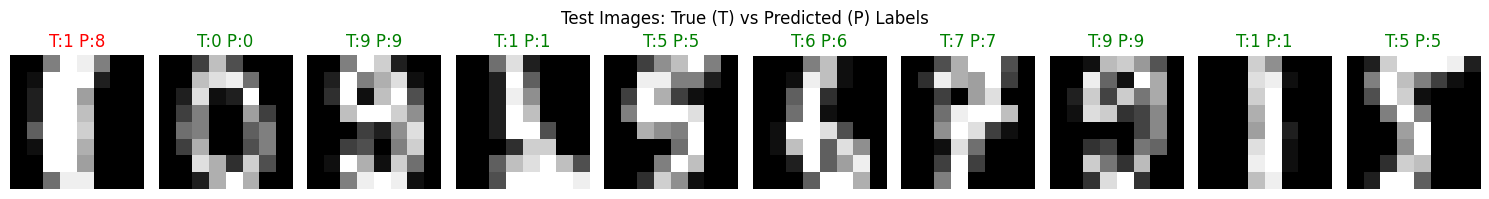

In [ ]:
# Display 10 test images with true and predicted labels
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    ax = axes[i]
    ax.imshow(X_test[i].reshape(8, 8), cmap='gray')
    color = 'green' if y_test[i] == y_test_pred[i] else 'red'
    ax.set_title(f"T:{y_test[i]} P:{y_test_pred[i]}", color=color)
    ax.axis('off')
plt.suptitle('Test Images: True (T) vs Predicted (P) Labels')
plt.tight_layout()
plt.show()

---
## Part 2: Multi-Label Properties

### 2(a) Load y_MLL_train.csv and y_MLL_test.csv

In [ ]:
# Already loaded above
print("Multi-label data loaded.")
print(f"Labels: [is_even, is_greater_than_5, is_prime]")
print(f"y_MLL_train sample:\n{y_MLL_train[:5]}")

Multi-label data loaded.
Labels: [is_even, is_greater_than_5, is_prime]
y_MLL_train sample:
[[1 0 1]
 [0 0 0]
 [1 0 1]
 [0 0 0]
 [0 1 1]]


### 2(b) Train three independent sigmoid logistic regression models

In [ ]:
# Train separate binary logistic regression for each property
property_names = ['is_even', 'is_greater_than_5', 'is_prime']
models_part2 = []

for i, prop in enumerate(property_names):
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_train_scaled, y_MLL_train[:, i])
    models_part2.append(model)
    print(f"Trained model for {prop}")

Trained model for is_even
Trained model for is_greater_than_5
Trained model for is_prime


### 2(c) Report training and test accuracy for each property

In [ ]:
print("Part 2 Results: Multi-Label Classification (using raw pixels X)\n")

part2_train_acc = []
part2_test_acc = []

for i, prop in enumerate(property_names):
    model = models_part2[i]

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_MLL_train[:, i], train_pred)
    test_acc = accuracy_score(y_MLL_test[:, i], test_pred)

    part2_train_acc.append(train_acc)
    part2_test_acc.append(test_acc)

    print(f"{prop}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:     {test_acc:.4f}")
    print()

Part 2 Results: Multi-Label Classification (using raw pixels X)

is_even:
  Training Accuracy: 0.9280
  Test Accuracy:     0.9133

is_greater_than_5:
  Training Accuracy: 0.9057
  Test Accuracy:     0.8644

is_prime:
  Training Accuracy: 0.9703
  Test Accuracy:     0.9511



---
## Part 3: The Hierarchical Bridge

### 3(a) Compute 10-class probability vector p(x) using softmax model from Part 1

In [ ]:
# Get probability vectors from softmax model
p_train = softmax_model.predict_proba(X_train_scaled)
p_test = softmax_model.predict_proba(X_test_scaled)

print(f"p_train shape: {p_train.shape}  # p(y=0|x), p(y=1|x), ..., p(y=9|x)")
print(f"p_test shape: {p_test.shape}")
print(f"\nSample probability vector (first training example): {p_train[0]}")

p_train shape: (1347, 10)  # p(y=0|x), p(y=1|x), ..., p(y=9|x)
p_test shape: (450, 10)

Sample probability vector (first training example): [2.99849414e-05 6.38820521e-07 9.85613349e-01 1.26224027e-02
 5.50057554e-09 4.99453281e-04 3.15608034e-05 1.29268131e-06
 3.93805587e-04 8.07506477e-04]


### 3(b) Construct new feature matrix X_new whose rows are p(x_i)

In [ ]:
# X_new is just the probability vectors
X_new_train = p_train
X_new_test = p_test

print(f"X_new_train shape: {X_new_train.shape}")
print(f"X_new_test shape: {X_new_test.shape}")

X_new_train shape: (1347, 10)
X_new_test shape: (450, 10)


### 3(c) Train new logistic regression models on X_new to predict is_even, is_greater_than_5, is_prime

In [ ]:
# Train models on probability features
models_part3 = []

for i, prop in enumerate(property_names):
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X_new_train, y_MLL_train[:, i])
    models_part3.append(model)
    print(f"Trained model for {prop} using p(x)")

Trained model for is_even using p(x)
Trained model for is_greater_than_5 using p(x)
Trained model for is_prime using p(x)


### 3(d) Report training and test accuracy, compare to Part 2 baseline

In [ ]:
print("Part 3 Results: Multi-Label Classification (using probability features p(x))\n")

part3_train_acc = []
part3_test_acc = []

for i, prop in enumerate(property_names):
    model = models_part3[i]

    train_pred = model.predict(X_new_train)
    test_pred = model.predict(X_new_test)

    train_acc = accuracy_score(y_MLL_train[:, i], train_pred)
    test_acc = accuracy_score(y_MLL_test[:, i], test_pred)

    part3_train_acc.append(train_acc)
    part3_test_acc.append(test_acc)

    print(f"{prop}:")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:     {test_acc:.4f}")
    print()

Part 3 Results: Multi-Label Classification (using probability features p(x))

is_even:
  Training Accuracy: 1.0000
  Test Accuracy:     0.9867

is_greater_than_5:
  Training Accuracy: 1.0000
  Test Accuracy:     0.9867

is_prime:
  Training Accuracy: 1.0000
  Test Accuracy:     0.9956



In [ ]:
# Comparison Table
print("COMPARISON: Part 2 (raw pixels X) vs Part 3 (probability features p(x))\n")
print(f"{'Property':<20} {'Part2 Train':<12} {'Part2 Test':<12} {'Part3 Train':<12} {'Part3 Test':<12}")
for i, prop in enumerate(property_names):
    print(f"{prop:<20} {part2_train_acc[i]:<12.4f} {part2_test_acc[i]:<12.4f} {part3_train_acc[i]:<12.4f} {part3_test_acc[i]:<12.4f}")

COMPARISON: Part 2 (raw pixels X) vs Part 3 (probability features p(x))

Property             Part2 Train  Part2 Test   Part3 Train  Part3 Test  
is_even              0.9280       0.9133       1.0000       0.9867      
is_greater_than_5    0.9057       0.8644       1.0000       0.9867      
is_prime             0.9703       0.9511       1.0000       0.9956      


### 3(e) Discussion.

**Discussion:**

Using p(x) (the 10-class digit probability vector) is a **strong representation** for predicting properties like `is_even`, `is_greater_than_5`, and `is_prime` compared to using raw pixels X. Here's why:

1. **Direct encoding of digit identity**: The probability vector p(x) essentially tells us "how likely is this image to be digit 0, 1, 2, ..., 9". Since the properties we're predicting are deterministic functions of the digit identity:
   - `is_even`: True for digits {0, 2, 4, 6, 8}
   - `is_greater_than_5`: True for digits {6, 7, 8, 9}
   - `is_prime`: True for digits {2, 3, 5, 7}
   
   The model can simply learn to weight the relevant digit probabilities.

2. **Dimensionality reduction**: p(x) has only 10 features compared to 64 pixel features, reducing model complexity and potential overfitting.

3. **Hierarchical knowledge transfer**: The softmax model has already learned to extract digit-relevant features from pixels. The properties model leverages this learned representation rather than learning from scratch.

4. **Theoretical justification**: For a perfectly accurate digit classifier, p(x) would be sufficient statistics for computing any digit-based property. The properties become simple linear combinations of the probabilities.

The comparison above should show that using p(x) achieves comparable or better accuracy with a much simpler model, demonstrating the power of hierarchical feature learning.